In [1]:
import os
import json
import networkx as nx
import matplotlib.pyplot as plt

In [2]:
files = "./logs-backup-20250805-214454"

In [3]:
def create_node_graph_dict(directory):
    node_id_to_name = {}
    node_graph = {}
    node_cnt = 0
    for filename in os.listdir(directory):
        filepath = os.path.join(directory, filename)
        if not os.path.isfile(filepath):
            continue
        with open(filepath, 'r', encoding='utf-8') as f:
            for line in f:
                if 'List of neighbors' in line:
                    d = json.loads(line)
                    node_graph[d['node_id']] = d.get('neighbors', [])
                    if d['node_id'] not in node_id_to_name:
                        node_id_to_name[d['node_id']] = f"node_{node_cnt}"
                        node_cnt += 1

    return node_id_to_name, node_graph

In [4]:
def build_directed_graph(node_names, graph):
    """
    Scans all files in `directory`, extracts nodes and neighbors, and builds a NetworkX DiGraph.
    """

    G = nx.DiGraph()

    for node, neighbors in graph.items():
        node_name = node_names[node]  
        G.add_node(node_name)
        for nbr in neighbors:
            if nbr in node_names:
                nbr_name = node_names[nbr]
            else:
                nbr_name = nbr
            G.add_node(nbr_name)
            G.add_edge(node_name, nbr_name)

    return G

In [5]:
def visualize_directed_graph(G, figsize=(12, 12), with_labels=True):
    # Project to undirected for consistent layout
    pos = nx.spring_layout(G, seed=42)
    plt.figure(figsize=figsize)

    # Separate edges by reciprocity
    solid_edges = []  # bidirectional
    dashed_edges = []  # one-way
    for u, v in G.edges():
        if G.has_edge(v, u):
            # ensure each is drawn only once
            if (v, u) not in solid_edges:
                solid_edges.append((u, v))
        else:
            dashed_edges.append((u, v))

    # Draw nodes and labels
    nx.draw_networkx_nodes(G, pos, node_size=300)
    if with_labels:
        nx.draw_networkx_labels(G, pos)

    # Draw bidirectional edges as solid undirected
    if solid_edges:
        nx.draw_networkx_edges(
            G.to_undirected(), pos,
            edgelist=solid_edges,
            style='solid',
            arrows=False
        )
    # Draw one-way edges as dashed with arrows
    if dashed_edges:
        nx.draw_networkx_edges(
            G, pos,
            edgelist=dashed_edges,
            style='dashed',
            arrows=True
        )

    plt.title("Directed Neighbor Graph (one-way edges dashed)")
    plt.axis('off')
    plt.show()

In [6]:
nodes, graph = create_node_graph_dict(files)

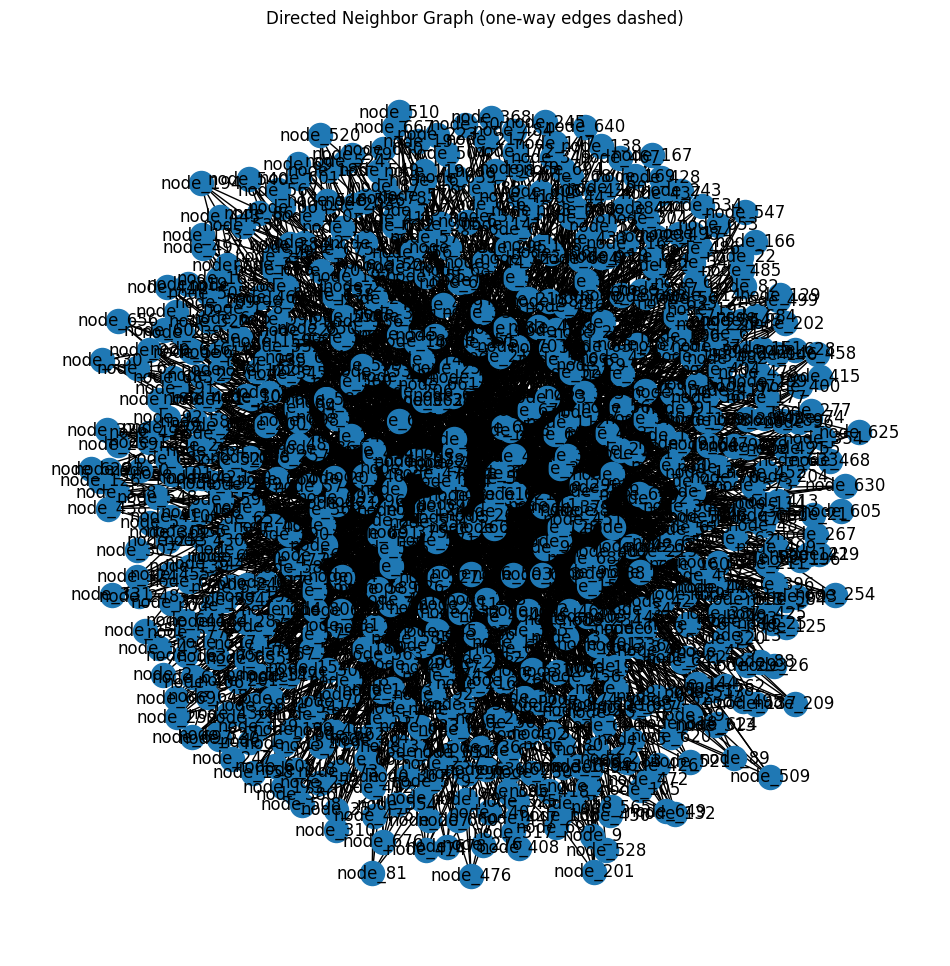

Number of connected components: 1
Component 1 (size 700): {'node_396', 'node_671', 'node_122', 'node_150', 'node_457', 'node_404', 'node_90', 'node_177', 'node_694', 'node_394', 'node_328', 'node_84', 'node_541', 'node_159', 'node_610', 'node_424', 'node_553', 'node_272', 'node_673', 'node_603', 'node_451', 'node_98', 'node_76', 'node_445', 'node_74', 'node_166', 'node_460', 'node_63', 'node_570', 'node_271', 'node_681', 'node_262', 'node_68', 'node_483', 'node_235', 'node_406', 'node_494', 'node_256', 'node_30', 'node_360', 'node_355', 'node_49', 'node_298', 'node_560', 'node_415', 'node_113', 'node_519', 'node_405', 'node_357', 'node_559', 'node_321', 'node_370', 'node_158', 'node_417', 'node_243', 'node_127', 'node_356', 'node_305', 'node_111', 'node_497', 'node_593', 'node_680', 'node_77', 'node_197', 'node_5', 'node_6', 'node_588', 'node_664', 'node_327', 'node_280', 'node_333', 'node_120', 'node_85', 'node_466', 'node_558', 'node_561', 'node_533', 'node_134', 'node_12', 'node_50'

In [7]:
nodes, graph = create_node_graph_dict(files)
G = build_directed_graph(nodes, graph)

# Visualize directed graph
visualize_directed_graph(G)

# Analyze undirected projection for components and diameter
U = G.to_undirected()
comps = list(nx.connected_components(U))
print(f"Number of connected components: {len(comps)}")
for i, comp in enumerate(comps, 1):
    print(f"Component {i} (size {len(comp)}): {comp}")

for i, comp in enumerate(comps, 1):
    if len(comp) > 1:
        subU = U.subgraph(comp)
        diam = nx.diameter(subU)
        print(f"Diameter of component {i}: {diam}")
    else:
        print(f"Component {i} has a single node; diameter undefined.")

In [8]:
def analyze_committee(directory):
    all_committees = {}
    for filename in os.listdir(directory):
        filepath = os.path.join(directory, filename)
        if not os.path.isfile(filepath):
            continue
        with open(filepath, 'r', encoding='utf-8') as f:
            for line in f:
                if "Committee elected" in line:
                    d = json.loads(line)
                    node_id = d["node_id"]  
                    committee = d["committee"]
                    all_committees[node_id] = [id["ID"] for id in committee]
    return all_committees

In [9]:
member_to_nodes = analyze_committee(files)

In [10]:
committee = set()
minimal_committee = 200
for k, v in member_to_nodes.items():
    print(k, len(v))
    minimal_committee = min(minimal_committee, len(v))
    for c in v:
        committee.add(c)

print(len(committee))
print(minimal_committee)

12D3KooWGdNQ8cgVrFPDtafAMmCjJQQycjNopfeRDHTq1QZD7WDe 676
12D3KooWB3w6iykUkycAtgh8hfah18aPdg4J8tcKVM7KaWLk6xoh 683
12D3KooWPQbD9JQvL6VDEPkerM3oQ6hqShBKiJfHP3qXKwuAi6P1 673
12D3KooWRDZoF74Q5Xq2Gr2jHacbruGpiqZSspKxas5axxt75MP2 669
12D3KooWKsxXd7rdM23yB654yS1o5QytoeDZZcJ4JiUPJKvY7skD 672
12D3KooWFDRSNtPLx1ie9BBqw6653LU5wvQA2VjSPoVRyeiwCW5e 687
12D3KooWLQMAR2JLBLXMabbZ2msjQTCY34Ra4ZReaDyibG9yFx8S 681
12D3KooWQ24qP2EFMk9Vg4a1AoPxhBFHPUX4pQ6seDTcxMijzvAm 700
12D3KooWFzjk87ED9PqknKHrkhHfNk2ZAkoz4jjFAiNUDyAMrhXZ 700
12D3KooWLH7Mz84jfaPZQHeFsC66ux4r23oLpQTmt5yq7fjdcvSp 669
12D3KooWQLjGjx4RfQvcbXeteekMfxm5F5mXYrozFS4BSgc6vaY1 684
12D3KooWR4yossb5JxxH6TramxetN9XoUj7isCVHgwT6L88JaGvA 700
12D3KooWARtEU9PiKi4ut2HPybn48bNQCx5UouuGRxDUWMAnGgeh 681
12D3KooWCDYJa1SHm1C2xFDxnHPDsi3b8wsYYWVP1V7YddX19SP3 681
12D3KooWF9cR7i3ZKx8Z43nZfeXP8m4U3JCkXbNEemRdf6b6v6e5 685
12D3KooWDTtdJWrJJ7At5C6448ccPRPTCS1ekqYsKSc3X1v1tTHu 689
12D3KooWSrbUUpHEVp97mkGQkvKjTzmqYAHmVpmf2Py4eKwFdRLL 677
12D3KooWFhgdZWoaq8kKYQN8TATE8fg

In [11]:
import subprocess

node_id = "12D3KooWDQ81qgvB42FNCwuaScYQHzxxmnxACAnjJC1G1vMdbs3n"

command1 = ["grep", "", "./logs-backup-20250805-191801/node-1-log.log"]
command2 = ["wc", "-l"]

for c in committee:
    if c == node_id:
        continue
    command1[1] = c
    p1 = subprocess.Popen(command1, stdout=subprocess.PIPE)
    p2 = subprocess.Popen(command2, stdin=p1.stdout, stdout=subprocess.PIPE)
    count = int(p2.stdout.read().decode("utf-8"))
    if count > 20:
        print(c, count)